# 2026 COMP90042 Project
*Make sure you change the file name with your group id.*

# Readme
*If there is something to be noted for the marker, please mention here.*

*If you are planning to implement a program with Object Oriented Programming style, please put those the bottom of this ipynb file*

# 1.DataSet Processing
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [10]:
# Installations
!pip install gdown rank_bm25 -q

# Downloading all files our shared google rive folder
!gdown --folder 1SvZNoUs0KVhZSp4pX3H2SI1VemDsfC90 -O /content/data

# Core
import json
import numpy as np
import pandas as pd
import string
import zipfile
from pathlib import Path
from collections import Counter
from tqdm.notebook import tqdm

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence

# HuggingFace
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    BertTokenizer,
    BertModel
)

# BM25
from rank_bm25 import BM25Okapi

# Sklearn
from sklearn.metrics import classification_report

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


DEPRECATION: Loading egg at /opt/anaconda3/lib/python3.12/site-packages/paramspider-0.1.0-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Retrieving folder contents
Processing file 1Px-nvmx0HDnHdHEYlkMlOuO9NxR0qnTU dev-claims-baseline.json
Processing file 1v9sUiPqun8sGMz5ZxynX97haJDAzpvRe dev-claims.json
Processing file 1jrrgqVHJiRbye_jYm08hp4GnngzSomtZ evidence.json
Processing file 1dFlfkJ0tLtr5VPwDvvje8CT0_STBm0jG test-claims-unlabelled.json
Processing file 1t3fnLNrml5H0K92LFy2hAcrh3BOAvk8u train-claims.json
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Error:

	[Errno 30] Read-only file system: '/content'

To report issues, please visit https://github.com/wkentaro/gdown/issues.


In [11]:
# Loading the data

DATA_DIR = Path("data")
TRAIN_PATH, DEV_PATH, TEST_PATH, EVIDENCE_PATH = [DATA_DIR / f for f in [
    "train-claims.json", "dev-claims.json",
    "test-claims-unlabelled.json", "evidence.json"
]]

with open(TRAIN_PATH) as f: train_claims = json.load(f)
with open(DEV_PATH) as f: dev_claims = json.load(f)
with open(TEST_PATH) as f: test_claims = json.load(f)
with open(EVIDENCE_PATH) as f: evidence = json.load(f)

print(f"Evidence passages: {len(evidence):,}\n")
print(f"Train claims: {len(train_claims)}")
print(f"Dev claims: {len(dev_claims)}")
print(f"Test claims: {len(test_claims)}")

Evidence passages: 1,208,827

Train claims: 1228
Dev claims: 154
Test claims: 153


In [12]:
# Data exploration

train_labels = [v['claim_label'] for v in train_claims.values()]
dev_labels = [v['claim_label'] for v in dev_claims.values()]
labels = ['SUPPORTS', 'REFUTES', 'NOT_ENOUGH_INFO', 'DISPUTED']

train_counts = Counter(train_labels)
dev_counts = Counter(dev_labels)

# Label distribution
label_distribution = pd.DataFrame({
    'Label': labels,
    'Train Count': [train_counts[l] for l in labels],
    'Train %': [f"{train_counts[l]/len(train_labels)*100:.1f}%" for l in labels],
    'Dev Count': [dev_counts[l] for l in labels],
    'Dev %': [f"{dev_counts[l]/len(dev_labels)*100:.1f}%" for l in labels],
})
print("LABEL DISTRIBUTION")
display(label_distribution)

train_ev_counts = [len(v['evidences']) for v in train_claims.values()]
dev_ev_counts = [len(v['evidences']) for v in dev_claims.values()]

# Evidence per claim stats
dataset_statistics = pd.DataFrame({
    'Split': ['Train', 'Dev'],
    'Claims': [len(train_claims), len(dev_claims)],
    'Min Evidence': [min(train_ev_counts), min(dev_ev_counts)],
    'Max Evidence': [max(train_ev_counts), max(dev_ev_counts)],
    'Avg Evidence': [f"{sum(train_ev_counts)/len(train_ev_counts):.2f}",
                     f"{sum(dev_ev_counts)/len(dev_ev_counts):.2f}"],
})
print("\nDATASET STATISTICS")
display(dataset_statistics)

# Sample claim
sample_id = list(train_claims.keys())[0]
sample = train_claims[sample_id]
print(f"\nSAMPLE CLAIM ({sample_id})")
print(f"Text:  {sample['claim_text']}")
print(f"Label: {sample['claim_label']}")

sample_evidence = pd.DataFrame({
    'Evidence ID': sample['evidences'],
    'Text': [evidence[ev_id][:120] + '...' for ev_id in sample['evidences']]
})
print("\nASSOCIATED EVIDENCE")
display(sample_evidence)

LABEL DISTRIBUTION


,Label,Train Count,Train %,Dev Count,Dev %
0,SUPPORTS,519,42.3%,68,44.2%
1,REFUTES,199,16.2%,27,17.5%
2,NOT_ENOUGH_INFO,386,31.4%,41,26.6%
3,DISPUTED,124,10.1%,18,11.7%



DATASET STATISTICS


,Split,Claims,Min Evidence,Max Evidence,Avg Evidence
0,Train,1228,1,5,3.36
1,Dev,154,1,5,3.19



SAMPLE CLAIM (claim-1937)
Text:  Not only is there no scientific evidence that CO2 is a pollutant, higher CO2 concentrations actually help ecosystems support more plant and animal life.
Label: DISPUTED

ASSOCIATED EVIDENCE


,Evidence ID,Text
0,evidence-442946,At very high concentrations (100 times atmosph...
1,evidence-1194317,Plants can grow as much as 50 percent faster i...
2,evidence-12171,Higher carbon dioxide concentrations will favo...


# 2.Model Implementation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [13]:
# Building the index over full evidence corpus (~1.2M  passages)

def preprocess(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text.split()

# Build corpus
print("Building BM25 index...")
evidence_ids = list(evidence.keys())
evidence_texts = [evidence[eid] for eid in evidence_ids]
tokenised_corpus = [preprocess(text) for text in evidence_texts]

bm25 = BM25Okapi(tokenised_corpus)
print(f"Index built over {len(evidence_ids):,} passages")

Building BM25 index...
Index built over 1,208,827 passages


In [14]:
# Retrieving the top-n candidate evidence passages for a given claim

def bm25_retrieve(claim_text, top_n=100):
    tokenised_query = preprocess(claim_text)
    scores = bm25.get_scores(tokenised_query)
    top_indices = np.argpartition(scores, -top_n)[-top_n:]
    top_indices = top_indices[np.argsort(scores[top_indices])[::-1]]
    return [(evidence_ids[i], scores[i]) for i in top_indices]

# Test on a sample claim
sample_id = list(train_claims.keys())[0]
sample_claim = train_claims[sample_id]['claim_text']
print(f"Claim: {sample_claim}\n")

results = bm25_retrieve(sample_claim, top_n=5)
print("Top 5 BM25 results:")
for ev_id, score in results:
    print(f"  [{ev_id}] (score: {score:.2f}) {evidence[ev_id][:120]}...")

Claim: Not only is there no scientific evidence that CO2 is a pollutant, higher CO2 concentrations actually help ecosystems support more plant and animal life.

Top 5 BM25 results:
  [evidence-66273] (score: 41.37) Higher atmospheric CO2 concentrations have led to an increase in dissolved CO2, which causes ocean acidification....
  [evidence-364767] (score: 39.26) It is expected that most ecosystems will be affected by higher atmospheric CO2 levels and higher global temperatures....
  [evidence-578065] (score: 33.33) Ball rejects not only CO2 greenhouse gas–induced climate change but the existence of the CO2 greenhouse effect itself....
  [evidence-1167485] (score: 31.87) Less direct geological evidence indicates that CO2 values have not been this high for millions of years....
  [evidence-247680] (score: 30.29) "How do we know more CO2 is causing warming?"....


In [15]:
# Loading the cross-encoder and re-ranking BM25 candidates by relevance

device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

print("Loading re-ranker model...")
reranker_tokenizer = AutoTokenizer.from_pretrained('cross-encoder/ms-marco-MiniLM-L-6-v2')
reranker_model = AutoModelForSequenceClassification.from_pretrained('cross-encoder/ms-marco-MiniLM-L-6-v2')
reranker_model = reranker_model.to(device)
reranker_model.eval()
print(f"Re-ranker loaded on {device}")

def rerank(claim_text, candidates, top_k=5):
    scores = []
    for ev_id, _ in candidates:
        ev_text = evidence[ev_id]
        inputs = reranker_tokenizer(
            claim_text, ev_text,
            return_tensors='pt',
            truncation=True,
            max_length=512,
            padding=True
        ).to(device)
        with torch.no_grad():
            score = reranker_model(**inputs).logits.squeeze().item()
        scores.append((ev_id, score))
    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:top_k]

# Testing the re-ranker on a sample claim
candidates = bm25_retrieve(sample_claim, top_n=50)
reranked = rerank(sample_claim, candidates, top_k=5)
print(f"\nClaim: {sample_claim}\n")
print("Top 5 Re-ranked results:")
for ev_id, score in reranked:
    print(f"  [{ev_id}] (score: {score:.4f}) {evidence[ev_id][:120]}...")

Using device: mps
Loading re-ranker model...
Re-ranker loaded on mps

Claim: Not only is there no scientific evidence that CO2 is a pollutant, higher CO2 concentrations actually help ecosystems support more plant and animal life.

Top 5 Re-ranked results:
  [evidence-1167485] (score: 2.3419) Less direct geological evidence indicates that CO2 values have not been this high for millions of years....
  [evidence-499734] (score: 0.8072) While the full implications of elevated CO2 on marine ecosystems are still being documented, there is a substantial body...
  [evidence-364767] (score: 0.0536) It is expected that most ecosystems will be affected by higher atmospheric CO2 levels and higher global temperatures....
  [evidence-12425] (score: -0.0868) To increase yield further, some sealed greenhouses inject CO2 into their environment to help improve growth and plant fe...
  [evidence-962456] (score: -0.5158) "Paleobotanical Evidence for Near Present-Day Levels of Atmospheric CO2 During Part o

In [16]:
# Applying the retriever + Re-ranker on full corpus pipeline
# BM25 retrieves top-100 candidates, transformer re-ranker scores each (claim, evidence) pair

def retrieve_and_rerank(claim_text, top_n_bm25=100, top_k=5):
    candidates = bm25_retrieve(claim_text, top_n=top_n_bm25)
    reranked = rerank(claim_text, candidates, top_k=top_k)
    return reranked

def evaluate_retrieval(claims_dict, top_k=5):
    f_scores = []
    for claim_id, claim_data in tqdm(claims_dict.items(), desc="Evaluating"):
        gold = set(claim_data['evidences'])
        retrieved = set([ev_id for ev_id, _ in retrieve_and_rerank(claim_data['claim_text'], top_k=top_k)])

        if len(retrieved) == 0:
            f_scores.append(0)
            continue

        precision = len(gold & retrieved) / len(retrieved)
        recall = len(gold & retrieved) / len(gold)
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0
        f_scores.append(f1)

    return sum(f_scores) / len(f_scores)

print("Evaluating BM25 + Re-ranker on dev set...")
reranker_f_score = evaluate_retrieval(dev_claims, top_k=5)
print(f"BM25 full corpus F-score (dev):        0.1003")
print(f"BM25 + Re-ranker F-score (dev):        {reranker_f_score:.4f}")
print(f"Baseline F-score (specsheet):          0.3378")

Evaluating BM25 + Re-ranker on dev set...


Evaluating:   0%|          | 0/154 [00:00<?, ?it/s]

BM25 full corpus F-score (dev):        0.1003
BM25 + Re-ranker F-score (dev):        0.1559
Baseline F-score (specsheet):          0.3378


In [17]:
# BM25 curated pool + re-ranker
# Building a BM25 index over the curated evidence pool (3,443 passages referenced in train+dev)
# then applying the transformer re-ranker to return top-k evidence for a given claim

curated_eids = set()
for item in train_claims.values():
    curated_eids.update(item['evidences'])
for item in dev_claims.values():
    curated_eids.update(item['evidences'])

curated_ids = list(curated_eids)
curated_texts = [evidence[eid] for eid in curated_ids]
print(f"Curated pool: {len(curated_ids)} passages")

# Build BM25 index over curated pool
print("Building curated BM25 index...")
curated_tokenised = [preprocess(text) for text in curated_texts]
bm25_curated = BM25Okapi(curated_tokenised)
print("Done!")

def retrieve_and_rerank_curated(claim_text, top_n_bm25=50, top_k=5):
    tokenised_query = preprocess(claim_text)
    scores = bm25_curated.get_scores(tokenised_query)
    top_indices = np.argpartition(scores, -top_n_bm25)[-top_n_bm25:]
    top_indices = top_indices[np.argsort(scores[top_indices])[::-1]]
    candidates = [(curated_ids[i], scores[i]) for i in top_indices]
    return rerank(claim_text, candidates, top_k=top_k)

# Testing on a sample claim
results = retrieve_and_rerank_curated(sample_claim, top_k=5)
print(f"\nClaim: {sample_claim}\n")
print("Top 5 results (curated pool + re-ranker):")
for ev_id, score in results:
    print(f"  [{ev_id}] (score: {score:.4f}) {evidence[ev_id][:120]}...")

Curated pool: 3443 passages
Building curated BM25 index...
Done!

Claim: Not only is there no scientific evidence that CO2 is a pollutant, higher CO2 concentrations actually help ecosystems support more plant and animal life.

Top 5 results (curated pool + re-ranker):
  [evidence-1167485] (score: 2.3419) Less direct geological evidence indicates that CO2 values have not been this high for millions of years....
  [evidence-442946] (score: 1.1732) At very high concentrations (100 times atmospheric concentration, or greater), carbon dioxide can be toxic to animal lif...
  [evidence-499734] (score: 0.8072) While the full implications of elevated CO2 on marine ecosystems are still being documented, there is a substantial body...
  [evidence-12171] (score: 0.4034) Higher carbon dioxide concentrations will favourably affect plant growth and demand for water....
  [evidence-364767] (score: 0.0536) It is expected that most ecosystems will be affected by higher atmospheric CO2 levels and higher 

In [18]:
# Retrieval Evaluation
# Evaluating the curated pool + re-ranker F-score on a dev set
# Note: This is the main retrieval result used in the report

def evaluate_curated_reranker(claims_dict, top_k=5):
    f_scores = []
    for claim_id, claim_data in tqdm(claims_dict.items(), desc="Evaluating"):
        gold = set(claim_data['evidences'])
        retrieved = set([ev_id for ev_id, _ in retrieve_and_rerank_curated(
            claim_data['claim_text'], top_k=top_k)])

        if len(retrieved) == 0:
            f_scores.append(0)
            continue

        precision = len(gold & retrieved) / len(retrieved)
        recall = len(gold & retrieved) / len(gold)
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0
        f_scores.append(f1)

    return sum(f_scores) / len(f_scores)

print("Evaluating curated pool + re-ranker on dev set...")
curated_reranker_f_score = evaluate_curated_reranker(dev_claims, top_k=5)

print(f"\n{'='*50}")
print(f"BM25 full corpus:              0.1003")
print(f"BM25 + re-ranker full corpus:  0.1559")
print(f"Curated + re-ranker:           {curated_reranker_f_score:.4f}")
print(f"Baseline (specsheet):          0.3378")
print(f"{'='*50}")

Evaluating curated pool + re-ranker on dev set...


Evaluating:   0%|          | 0/154 [00:00<?, ?it/s]


BM25 full corpus:              0.1003
BM25 + re-ranker full corpus:  0.1559
Curated + re-ranker:           0.2465
Baseline (specsheet):          0.3378


In [19]:
# Per-sentence verdict classifier (Novel contribution #1)
# Each retrieved evidence sentence is independently classified as SUPPORTS, REFUTES, or IRRELEVANT
# using an NLI cross-encoder (nli-MiniLM2-L6-H768).
# Label map: {0: contradiction > REFUTES, 1: entailment > SUPPORTS, 2: neutral > IRRELEVANT}
# Threshold: 0.10 where evidence is classified as SUPPORTS/REFUTES only if probability exceeds threshold

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

print("Loading NLI model for per-sentence verdict...")
nli_tokenizer = AutoTokenizer.from_pretrained('cross-encoder/nli-MiniLM2-L6-H768')
nli_model = AutoModelForSequenceClassification.from_pretrained('cross-encoder/nli-MiniLM2-L6-H768')
nli_model = nli_model.to(device)
nli_model.eval()
print("NLI model loaded!")

def get_sentence_verdict(claim_text, evidence_text, threshold=0.10):
    """Classify each evidence sentence as SUPPORTS, REFUTES, or IRRELEVANT."""
    inputs = nli_tokenizer(
        claim_text, evidence_text,
        return_tensors='pt',
        truncation=True,
        max_length=512,
        padding=True
    ).to(device)
    with torch.no_grad():
        logits = nli_model(**inputs).logits
    probs = torch.softmax(logits, dim=-1).squeeze()

    contradiction_prob = probs[0].item()
    entailment_prob = probs[1].item()

    if entailment_prob > threshold and entailment_prob > contradiction_prob:
        verdict = 'SUPPORTS'
    elif contradiction_prob > threshold and contradiction_prob > entailment_prob:
        verdict = 'REFUTES'
    else:
        verdict = 'IRRELEVANT'

    return verdict, probs.tolist()

# Testing on a sample claim
print(f"\nClaim: {sample_claim}")
print(f"Ground truth label: {train_claims[sample_id]['claim_label']}\n")
for ev_id, score in results:
    verdict, probs = get_sentence_verdict(sample_claim, evidence[ev_id])
    print(f"[{verdict}] (S:{probs[1]:.2f} R:{probs[0]:.2f} I:{probs[2]:.2f}) {evidence[ev_id][:100]}...")

Using device: mps
Loading NLI model for per-sentence verdict...


/opt/anaconda3/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


NLI model loaded!

Claim: Not only is there no scientific evidence that CO2 is a pollutant, higher CO2 concentrations actually help ecosystems support more plant and animal life.
Ground truth label: DISPUTED

[IRRELEVANT] (S:0.00 R:0.00 I:0.99) Less direct geological evidence indicates that CO2 values have not been this high for millions of ye...
[IRRELEVANT] (S:0.00 R:0.05 I:0.95) At very high concentrations (100 times atmospheric concentration, or greater), carbon dioxide can be...
[REFUTES] (S:0.02 R:0.38 I:0.60) While the full implications of elevated CO2 on marine ecosystems are still being documented, there i...
[REFUTES] (S:0.01 R:0.12 I:0.87) Higher carbon dioxide concentrations will favourably affect plant growth and demand for water....
[IRRELEVANT] (S:0.00 R:0.04 I:0.96) It is expected that most ecosystems will be affected by higher atmospheric CO2 levels and higher glo...


In [20]:
# Evidence consistency aggregation (Novel contribution #2)
# Aggregates per-sentence verdicts into a final label prediction
# Directly addresses DISPUTED class handling noted as future work in Diggelmann et al. (2021)

def aggregate_evidence(claim_text, evidence_ids_list):
    """
    Aggregate per-sentence verdicts into a consistency signal.

    Verdict patterns -> Final label:
    - Mix of SUPPORTS + REFUTES -> DISPUTED
    - 2+ SUPPORTS -> SUPPORTS
    - 2+ REFUTES -> REFUTES
    - Otherwise -> NOT_ENOUGH_INFO
    """
    verdicts = []
    for ev_id in evidence_ids_list:
        verdict, probs = get_sentence_verdict(claim_text, evidence[ev_id])
        verdicts.append(verdict)

    supports = verdicts.count('SUPPORTS')
    refutes = verdicts.count('REFUTES')

    if supports > 0 and refutes > 0:
        consistency = 'CONFLICT'
        predicted_label = 'DISPUTED'
    elif supports >= 2:
        consistency = 'AGREE_SUPPORT'
        predicted_label = 'SUPPORTS'
    elif refutes >= 2:
        consistency = 'AGREE_REFUTE'
        predicted_label = 'REFUTES'
    elif supports == 1:
        consistency = 'WEAK_SUPPORT'
        predicted_label = 'SUPPORTS'
    elif refutes == 1:
        consistency = 'WEAK_REFUTE'
        predicted_label = 'REFUTES'
    else:
        consistency = 'WEAK'
        predicted_label = 'NOT_ENOUGH_INFO'

    return predicted_label, consistency, verdicts

# Testing on a sample claim
predicted, consistency, verdicts = aggregate_evidence(
    sample_claim,
    [ev_id for ev_id, _ in results]
)
print(f"Claim: {sample_claim}")
print(f"Ground truth:  {train_claims[sample_id]['claim_label']}")
print(f"Predicted:     {predicted}")
print(f"Consistency:   {consistency}")
print(f"Verdicts:      {verdicts}")

Claim: Not only is there no scientific evidence that CO2 is a pollutant, higher CO2 concentrations actually help ecosystems support more plant and animal life.
Ground truth:  DISPUTED
Predicted:     REFUTES
Consistency:   AGREE_REFUTE
Verdicts:      ['IRRELEVANT', 'IRRELEVANT', 'REFUTES', 'REFUTES', 'IRRELEVANT']


In [21]:
# Evidence consistency aggregation on dev set
# This tests the novelty contribution on its own, before the BiLSTM classifier is applied

from tqdm.notebook import tqdm

def predict_claim(claim_text, top_k=5):
    retrieved = retrieve_and_rerank_curated(claim_text, top_k=top_k)
    evidence_ids_list = [ev_id for ev_id, _ in retrieved]
    predicted_label, consistency, verdicts = aggregate_evidence(claim_text, evidence_ids_list)
    return predicted_label, evidence_ids_list, consistency, verdicts

# Evaluate on dev set
print("Evaluating full pipeline on dev set...")
correct = 0
total = 0
predictions = {}

for claim_id, claim_data in tqdm(dev_claims.items(), desc="Predicting"):
    predicted_label, ev_ids, consistency, verdicts = predict_claim(claim_data['claim_text'])
    predictions[claim_id] = {
        'claim_label': predicted_label,
        'evidences': ev_ids
    }
    if predicted_label == claim_data['claim_label']:
        correct += 1
    total += 1

accuracy = correct / total
print(f"\n{'='*50}")
print(f"Consistency Aggregation Accuracy: {accuracy:.4f}")
print(f"Baseline accuracy (specsheet):    0.3506")
print(f"{'='*50}")

Evaluating full pipeline on dev set...


Predicting:   0%|          | 0/154 [00:00<?, ?it/s]


Consistency Aggregation Accuracy: 0.2792
Baseline accuracy (specsheet):    0.3506


In [22]:
# Pre-compute the retrieved evidence for all splits
# Applying BM25 curated pool + transformer re-ranker to train/dev/test claims

print("Preparing retrieved evidence for train claims...")
train_claims_ret = {}
for cid, item in tqdm(train_claims.items(), desc="Train"):
    retrieved = retrieve_and_rerank_curated(item['claim_text'], top_k=5)
    train_claims_ret[cid] = {
        **item,
        'evidences': [ev_id for ev_id, _ in retrieved]
    }

print("Preparing retrieved evidence for dev claims...")
dev_claims_ret = {}
for cid, item in tqdm(dev_claims.items(), desc="Dev"):
    retrieved = retrieve_and_rerank_curated(item['claim_text'], top_k=5)
    dev_claims_ret[cid] = {
        **item,
        'evidences': [ev_id for ev_id, _ in retrieved]
    }

print("Preparing retrieved evidence for test claims...")
test_claims_ret = {}
for cid, item in tqdm(test_claims.items(), desc="Test"):
    retrieved = retrieve_and_rerank_curated(item['claim_text'], top_k=5)
    test_claims_ret[cid] = {
        **item,
        'evidences': [ev_id for ev_id, _ in retrieved]
    }

print("Done!")
print(f"Train: {len(train_claims_ret)} | Dev: {len(dev_claims_ret)} | Test: {len(test_claims_ret)}")

Preparing retrieved evidence for train claims...


Train:   0%|          | 0/1228 [00:00<?, ?it/s]

Preparing retrieved evidence for dev claims...


Dev:   0%|          | 0/154 [00:00<?, ?it/s]

Preparing retrieved evidence for test claims...


Test:   0%|          | 0/153 [00:00<?, ?it/s]

Done!
Train: 1228 | Dev: 154 | Test: 153


In [42]:
# Classifier Dataset - embedding extraction
# Supports CLS pooling (BERT, RoBERTa) and mean pooling (DeBERTa-v3)
# DeBERTa-v3 uses disentangled attention; its [CLS] is not trained for pooling

def get_embedding(text, model, tokenizer, device, max_len=128, pooling='cls'):
    """Encode text and return a [768] embedding.
    pooling='cls'  -> [CLS] token (position 0) -- suits BERT, RoBERTa
    pooling='mean' -> average over non-padding tokens -- suits DeBERTa-v3
    """
    inputs = tokenizer(
        text, return_tensors='pt', truncation=True,
        max_length=max_len, padding='max_length'
    ).to(device)
    with torch.no_grad():
        out = model(**inputs)
    if pooling == 'mean':
        mask = inputs['attention_mask'].unsqueeze(-1).float()          # [1, seq_len, 1]
        emb  = (out.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        return emb.squeeze(0).cpu()                                    # [768]
    else:
        return out.last_hidden_state[:, 0, :].squeeze(0).cpu()        # [768]


class ClaimEvidenceDataset(Dataset):
    """Pre-computes frozen encoder embeddings for all claims and their evidence.
    pooling: 'cls' for BERT/RoBERTa, 'mean' for DeBERTa-v3."""
    def __init__(self, claims_dict, evidence_corpus, label2idx, bert_model, tokenizer,
                 device, has_labels=True, pooling='cls'):
        self.samples = []
        bert_model.eval()
        for item in claims_dict.values():
            claim_emb = get_embedding(item['claim_text'], bert_model, tokenizer, device, pooling=pooling)
            ev_embs   = torch.stack([
                get_embedding(evidence_corpus[eid], bert_model, tokenizer, device, pooling=pooling)
                for eid in item['evidences']
            ])  # [n_ev, 768]
            label = label2idx[item['claim_label']] if has_labels else -1
            self.samples.append((claim_emb, ev_embs, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


def collate_fn(batch):
    claim_embs, ev_embs, labels = zip(*batch)
    claim_embs = torch.stack(claim_embs)                       # [B, 768]
    lengths    = torch.tensor([e.shape[0] for e in ev_embs])   # [B]
    padded_ev  = torch.zeros(len(ev_embs), lengths.max().item(), 768)
    for i, ev in enumerate(ev_embs):
        padded_ev[i, :ev.shape[0]] = ev                        # [B, max_ev, 768]
    return claim_embs, padded_ev, lengths, torch.tensor(labels)

In [43]:
# BiLSTM Classifier - To check sequence model over evidence embeddings (satisfies sequence modelling requirement)

class BiLSTMClaimClassifier(nn.Module):
    """
    Architecture:
      claim [CLS] vec  ─────────────────────────────────┐
                                                         ├─ concat ─► Linear ─► 4-class label
      evidence[0..n] [CLS] vecs ─► BiLSTM ─► fwd+bwd ──┘
    """
    def __init__(self, input_dim=768, hidden_dim=256, num_layers=2, num_classes=4, dropout=0.3):
        super().__init__()
        self.bilstm = nn.LSTM(
            input_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(768 + hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, claim_embs, ev_embs, lengths):
        # ev_embs: [B, max_ev, 768]
        packed = pack_padded_sequence(ev_embs, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.bilstm(packed)
        # h_n: [num_layers*2, B, hidden_dim] — take last layer forward + backward states
        ev_vec   = torch.cat([h_n[-2], h_n[-1]], dim=1)    # [B, hidden_dim*2]
        combined = torch.cat([claim_embs, ev_vec], dim=1)  # [B, 768 + hidden_dim*2]
        return self.classifier(combined)

In [44]:
# UniLSTM Classifier - Unidirectional baseline for comparison with BiLSTM

class UniLSTMClaimClassifier(nn.Module):
    """
    Unidirectional baseline for comparison with BiLSTMClaimClassifier.
    Fewer parameters (1.8M vs 4M) — used to assess whether bidirectionality helps.
    """
    def __init__(self, input_dim=768, hidden_dim=256, num_layers=2, num_classes=4, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(768 + hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, claim_embs, ev_embs, lengths):
        packed = pack_padded_sequence(ev_embs, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        ev_vec   = h_n[-1]
        combined = torch.cat([claim_embs, ev_vec], dim=1)
        return self.classifier(combined)

In [45]:
# Encoder Setup - Load BERT, pre-compute frozen CLS embeddings for all splits
# BERT weights frozen to reduce compute and prevent overfitting on small dataset

evidence_corpus = evidence
LABEL2IDX = {'SUPPORTS': 0, 'REFUTES': 1, 'NOT_ENOUGH_INFO': 2, 'DISPUTED': 3}
IDX2LABEL = {v: k for k, v in LABEL2IDX.items()}

device = torch.device(
    'mps' if torch.backends.mps.is_available()
    else 'cuda' if torch.cuda.is_available()
    else 'cpu'
)
print(f"Using device: {device}")

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert      = BertModel.from_pretrained('bert-base-uncased').to(device)
for param in bert.parameters():
    param.requires_grad = False
bert.eval()

print("Pre-computing BERT embeddings for train set...")
train_dataset    = ClaimEvidenceDataset(train_claims_ret, evidence_corpus, LABEL2IDX, bert, tokenizer, device)
print("Pre-computing BERT embeddings for dev set (gold evidence)...")
dev_dataset_gold = ClaimEvidenceDataset(dev_claims,       evidence_corpus, LABEL2IDX, bert, tokenizer, device)
print("Pre-computing BERT embeddings for dev set (retrieved evidence)...")
dev_dataset_ret  = ClaimEvidenceDataset(dev_claims_ret,   evidence_corpus, LABEL2IDX, bert, tokenizer, device)

train_loader   = DataLoader(train_dataset,    batch_size=32, shuffle=True,  collate_fn=collate_fn)
dev_loader     = DataLoader(dev_dataset_gold, batch_size=32, shuffle=False, collate_fn=collate_fn)
dev_loader_ret = DataLoader(dev_dataset_ret,  batch_size=32, shuffle=False, collate_fn=collate_fn)

Using device: mps


A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Pl

Pre-computing BERT embeddings for train set...
Pre-computing BERT embeddings for dev set (gold evidence)...
Pre-computing BERT embeddings for dev set (retrieved evidence)...


In [83]:
# Training and evaluation functions

import matplotlib.pyplot as plt

def plot_training_history(history, title='Classifier'):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontweight='bold')

    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    axes[0].plot(epochs, history['val_loss'],   'r-', label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss per Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], 'b-', label='Train Accuracy')
    axes[1].plot(epochs, history['val_acc'],   'r-', label='Val Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy per Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def train_model(model, train_loader, dev_loader, device, epochs=15, lr=1e-3, verbose=True):
    counts  = Counter(s[2] for s in train_loader.dataset.samples)
    total   = sum(counts.values())
    weights = torch.tensor([total / counts[i] for i in range(4)], dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    best_acc, best_state = 0.0, None
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        model.train()
        run_loss, correct, n_train = 0.0, 0, 0
        for claim_embs, ev_embs, lengths, labels in train_loader:
            claim_embs = claim_embs.to(device)
            ev_embs    = ev_embs.to(device)
            labels     = labels.to(device)

            optimizer.zero_grad()
            logits = model(claim_embs, ev_embs, lengths)
            loss   = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            run_loss += loss.item()
            correct  += (logits.argmax(1) == labels).sum().item()
            n_train  += labels.size(0)

        model.eval()
        val_loss, val_correct, n_val = 0.0, 0, 0
        with torch.no_grad():
            for claim_embs, ev_embs, lengths, labels in dev_loader:
                claim_embs = claim_embs.to(device)
                ev_embs    = ev_embs.to(device)
                labels     = labels.to(device)
                logits     = model(claim_embs, ev_embs, lengths)
                val_loss    += criterion(logits, labels).item()
                val_correct += (logits.argmax(1) == labels).sum().item()
                n_val       += labels.size(0)

        t_loss = run_loss / len(train_loader)
        v_loss = val_loss / len(dev_loader)
        t_acc  = correct     / n_train
        v_acc  = val_correct / n_val

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        if verbose:
            print(f"Epoch {epoch:2d} | Loss {t_loss:.4f} | Train Acc {t_acc:.4f} | Dev Acc {v_acc:.4f}")

        if v_acc > best_acc:
            best_acc   = v_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if verbose:
        print(f"\nBest dev accuracy: {best_acc:.4f}")
    model.load_state_dict(best_state)
    return model, history


def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for claim_embs, ev_embs, lengths, labels in loader:
            claim_embs = claim_embs.to(device)
            ev_embs    = ev_embs.to(device)
            preds = model(claim_embs, ev_embs, lengths).argmax(1).cpu().tolist()
            all_preds.extend(preds)
            all_labels.extend(labels.tolist())
    acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    return acc, (all_preds, all_labels)

Training BiLSTM Classifier
Epoch  1 | Loss 1.4023 | Train Acc 0.2875 | Dev Acc 0.4221
Epoch  2 | Loss 1.3510 | Train Acc 0.3379 | Dev Acc 0.4091
Epoch  3 | Loss 1.3456 | Train Acc 0.4055 | Dev Acc 0.3636
Epoch  4 | Loss 1.3326 | Train Acc 0.3730 | Dev Acc 0.4091
Epoch  5 | Loss 1.3134 | Train Acc 0.3982 | Dev Acc 0.3961
Epoch  6 | Loss 1.2851 | Train Acc 0.4218 | Dev Acc 0.2987
Epoch  7 | Loss 1.2451 | Train Acc 0.4186 | Dev Acc 0.4221
Epoch  8 | Loss 1.2551 | Train Acc 0.4161 | Dev Acc 0.3117
Epoch  9 | Loss 1.2376 | Train Acc 0.4292 | Dev Acc 0.4286
Epoch 10 | Loss 1.2027 | Train Acc 0.4593 | Dev Acc 0.4351
Epoch 11 | Loss 1.2026 | Train Acc 0.4674 | Dev Acc 0.3636
Epoch 12 | Loss 1.1853 | Train Acc 0.4544 | Dev Acc 0.3961
Epoch 13 | Loss 1.1357 | Train Acc 0.4805 | Dev Acc 0.4545
Epoch 14 | Loss 1.1523 | Train Acc 0.4910 | Dev Acc 0.3182
Epoch 15 | Loss 1.1387 | Train Acc 0.4715 | Dev Acc 0.3896
Epoch 16 | Loss 1.1284 | Train Acc 0.4837 | Dev Acc 0.4091
Epoch 17 | Loss 1.0582 | Trai

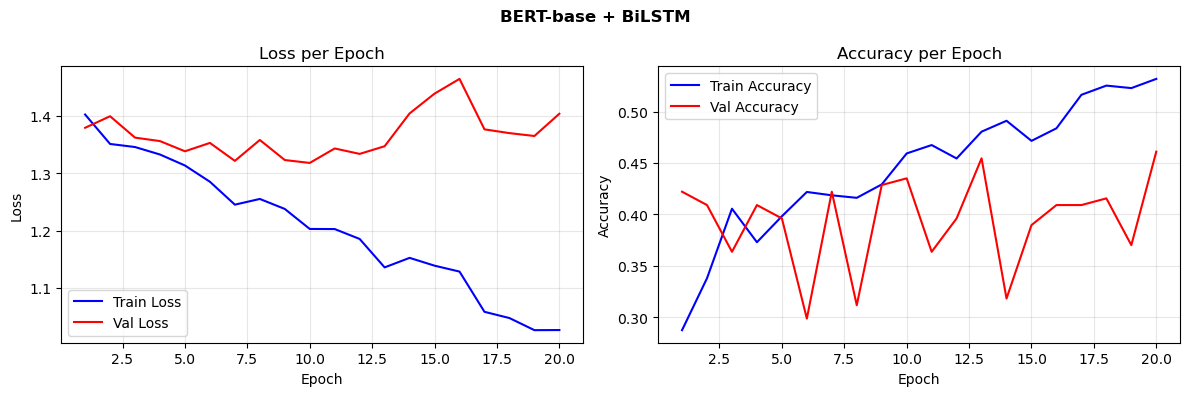


Training Unidirectional LSTM Classifier
Epoch  1 | Loss 1.4114 | Train Acc 0.2948 | Dev Acc 0.4091
Epoch  2 | Loss 1.3626 | Train Acc 0.2997 | Dev Acc 0.4026
Epoch  3 | Loss 1.3601 | Train Acc 0.3787 | Dev Acc 0.3961
Epoch  4 | Loss 1.3183 | Train Acc 0.3542 | Dev Acc 0.3312
Epoch  5 | Loss 1.3166 | Train Acc 0.4047 | Dev Acc 0.3896
Epoch  6 | Loss 1.2810 | Train Acc 0.4226 | Dev Acc 0.4091
Epoch  7 | Loss 1.2779 | Train Acc 0.3966 | Dev Acc 0.3506
Epoch  8 | Loss 1.2669 | Train Acc 0.4349 | Dev Acc 0.3961
Epoch  9 | Loss 1.2498 | Train Acc 0.4454 | Dev Acc 0.3701
Epoch 10 | Loss 1.2245 | Train Acc 0.4365 | Dev Acc 0.3636
Epoch 11 | Loss 1.2113 | Train Acc 0.4593 | Dev Acc 0.4286
Epoch 12 | Loss 1.1845 | Train Acc 0.4479 | Dev Acc 0.4610
Epoch 13 | Loss 1.1889 | Train Acc 0.4699 | Dev Acc 0.3961
Epoch 14 | Loss 1.1980 | Train Acc 0.4511 | Dev Acc 0.4091
Epoch 15 | Loss 1.1511 | Train Acc 0.4886 | Dev Acc 0.3506
Epoch 16 | Loss 1.1301 | Train Acc 0.5000 | Dev Acc 0.4091
Epoch 17 | Loss

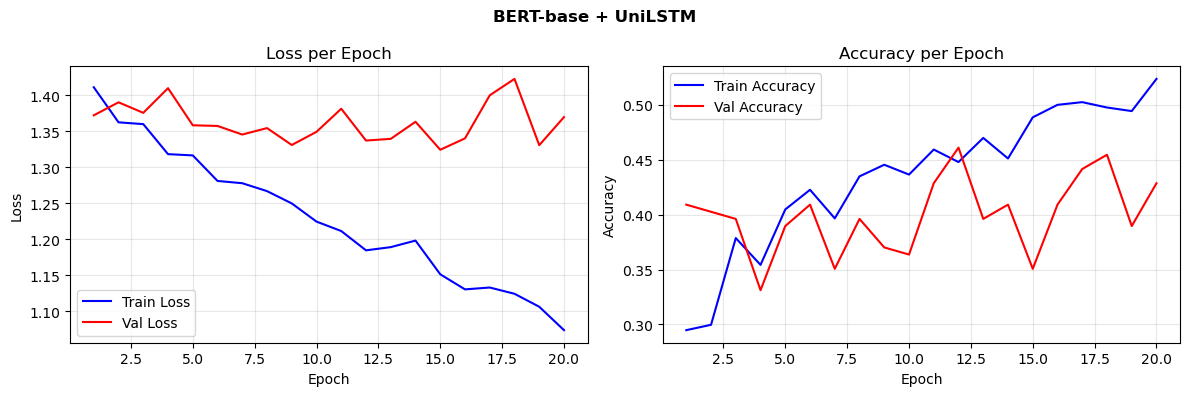


Model        Retrieved Dev   Gold Dev       Params
-----------------------------------------------------------------
BiLSTM              0.4610     0.5130    1,446,532
UniLSTM             0.4610     0.4805      707,204

BiLSTM classification report:
                 precision    recall  f1-score   support

       SUPPORTS       0.58      0.62      0.60        68
        REFUTES       0.56      0.37      0.44        27
NOT_ENOUGH_INFO       0.35      0.32      0.33        41
       DISPUTED       0.22      0.33      0.27        18

       accuracy                           0.46       154
      macro avg       0.43      0.41      0.41       154
   weighted avg       0.47      0.46      0.46       154

Unidirectional LSTM classification report:
                 precision    recall  f1-score   support

       SUPPORTS       0.56      0.66      0.60        68
        REFUTES       0.38      0.52      0.44        27
NOT_ENOUGH_INFO       0.53      0.20      0.29        41
       DISPUTED   

In [84]:
# Training BiLSTM and UniLSTM classifiers
# Both trained on retrieved evidence (curated pool + re-ranker) to match the test distribution.

# --- Train BiLSTM ---
print("=" * 50)
print("Training BiLSTM Classifier")
print("=" * 50)
model_bilstm = BiLSTMClaimClassifier(
    input_dim=768, hidden_dim=128, num_layers=2, num_classes=4, dropout=0.5
).to(device)
model_bilstm, bilstm_hist = train_model(model_bilstm, train_loader, dev_loader_ret, device, epochs=20, lr=1e-3)
plot_training_history(bilstm_hist, 'BERT-base + BiLSTM')

# --- Train Unidirectional LSTM ---
print("\n" + "=" * 50)
print("Training Unidirectional LSTM Classifier")
print("=" * 50)
model_unilstm = UniLSTMClaimClassifier(
    input_dim=768, hidden_dim=128, num_layers=2, num_classes=4, dropout=0.5
).to(device)
model_unilstm, unilstm_hist = train_model(model_unilstm, train_loader, dev_loader_ret, device, epochs=20, lr=1e-3)
plot_training_history(unilstm_hist, 'BERT-base + UniLSTM')

bilstm_acc,  (bilstm_preds,  dev_ret_labels) = evaluate(model_bilstm,  dev_loader_ret, device)
unilstm_acc, (unilstm_preds, _)              = evaluate(model_unilstm, dev_loader_ret, device)

# Secondary metric: gold-evidence dev (upper bound)
bilstm_gold,  _ = evaluate(model_bilstm,  dev_loader, device)
unilstm_gold, _ = evaluate(model_unilstm, dev_loader, device)

print("\n" + "=" * 65)
print(f"{'Model':<10} {'Retrieved Dev':>15} {'Gold Dev':>10} {'Params':>12}")
print("-" * 65)
print(f"{'BiLSTM':<10} {bilstm_acc:>15.4f} {bilstm_gold:>10.4f} "
      f"{sum(p.numel() for p in model_bilstm.parameters()):>12,}")
print(f"{'UniLSTM':<10} {unilstm_acc:>15.4f} {unilstm_gold:>10.4f} "
      f"{sum(p.numel() for p in model_unilstm.parameters()):>12,}")
print("=" * 65)

print("\nBiLSTM classification report:")
print(classification_report(dev_ret_labels, bilstm_preds,
                             target_names=[IDX2LABEL[i] for i in range(4)], zero_division=0))

print("Unidirectional LSTM classification report:")
print(classification_report(dev_ret_labels, unilstm_preds,
                             target_names=[IDX2LABEL[i] for i in range(4)], zero_division=0))

# Forward the better model to the test prediction cell
model      = model_bilstm  if bilstm_acc >= unilstm_acc else model_unilstm
model_name = "BiLSTM"      if bilstm_acc >= unilstm_acc else "UniLSTM"
print(f"Selected model for test predictions: {model_name}")

Grid search: BiLSTM
  [ 1/36] hidden= 64  dropout=0.3  lr=1e-05  ->  dev=0.3117
  [ 2/36] hidden= 64  dropout=0.3  lr=5e-04  ->  dev=0.4351
  [ 3/36] hidden= 64  dropout=0.3  lr=1e-03  ->  dev=0.4805
  [ 4/36] hidden= 64  dropout=0.3  lr=2e-03  ->  dev=0.4675
  [ 5/36] hidden= 64  dropout=0.4  lr=1e-05  ->  dev=0.3506
  [ 6/36] hidden= 64  dropout=0.4  lr=5e-04  ->  dev=0.4610
  [ 7/36] hidden= 64  dropout=0.4  lr=1e-03  ->  dev=0.4545
  [ 8/36] hidden= 64  dropout=0.4  lr=2e-03  ->  dev=0.4805
  [ 9/36] hidden= 64  dropout=0.5  lr=1e-05  ->  dev=0.3506
  [10/36] hidden= 64  dropout=0.5  lr=5e-04  ->  dev=0.4481
  [11/36] hidden= 64  dropout=0.5  lr=1e-03  ->  dev=0.4610
  [12/36] hidden= 64  dropout=0.5  lr=2e-03  ->  dev=0.4351
  [13/36] hidden=128  dropout=0.3  lr=1e-05  ->  dev=0.4675
  [14/36] hidden=128  dropout=0.3  lr=5e-04  ->  dev=0.4935
  [15/36] hidden=128  dropout=0.3  lr=1e-03  ->  dev=0.4610
  [16/36] hidden=128  dropout=0.3  lr=2e-03  ->  dev=0.4805
  [17/36] hidden=128

,hidden_dim,dropout,lr,dev_acc
0,256,0.3,0.0005,0.519481
1,128,0.3,0.0005,0.493506
2,64,0.3,0.0010,0.480519
3,128,0.3,0.0020,0.480519
4,64,0.4,0.0020,0.480519



Grid search: UniLSTM
  [ 1/36] hidden= 64  dropout=0.3  lr=1e-05  ->  dev=0.4481
  [ 2/36] hidden= 64  dropout=0.3  lr=5e-04  ->  dev=0.4221
  [ 3/36] hidden= 64  dropout=0.3  lr=1e-03  ->  dev=0.5065
  [ 4/36] hidden= 64  dropout=0.3  lr=2e-03  ->  dev=0.4545
  [ 5/36] hidden= 64  dropout=0.4  lr=1e-05  ->  dev=0.3831
  [ 6/36] hidden= 64  dropout=0.4  lr=5e-04  ->  dev=0.4351
  [ 7/36] hidden= 64  dropout=0.4  lr=1e-03  ->  dev=0.4416
  [ 8/36] hidden= 64  dropout=0.4  lr=2e-03  ->  dev=0.4221
  [ 9/36] hidden= 64  dropout=0.5  lr=1e-05  ->  dev=0.3312
  [10/36] hidden= 64  dropout=0.5  lr=5e-04  ->  dev=0.4221
  [11/36] hidden= 64  dropout=0.5  lr=1e-03  ->  dev=0.4351
  [12/36] hidden= 64  dropout=0.5  lr=2e-03  ->  dev=0.4156
  [13/36] hidden=128  dropout=0.3  lr=1e-05  ->  dev=0.3571
  [14/36] hidden=128  dropout=0.3  lr=5e-04  ->  dev=0.4610
  [15/36] hidden=128  dropout=0.3  lr=1e-03  ->  dev=0.4610
  [16/36] hidden=128  dropout=0.3  lr=2e-03  ->  dev=0.4610
  [17/36] hidden=1

,hidden_dim,dropout,lr,dev_acc
0,128,0.4,0.0010,0.506494
1,64,0.3,0.0010,0.506494
2,256,0.4,0.0020,0.493506
3,256,0.3,0.0005,0.487013
4,128,0.4,0.0020,0.480519



Best BiLSTM:  hidden=256  dropout=0.3  lr=5e-04
Best UniLSTM: hidden=128  dropout=0.4  lr=1e-03

Re-training BiLSTM (15 epochs)...
Epoch  1 | Loss 1.3870 | Train Acc 0.3046 | Dev Acc 0.2403
Epoch  2 | Loss 1.3306 | Train Acc 0.4096 | Dev Acc 0.3701
Epoch  3 | Loss 1.2839 | Train Acc 0.4308 | Dev Acc 0.3182
Epoch  4 | Loss 1.2120 | Train Acc 0.4495 | Dev Acc 0.3442
Epoch  5 | Loss 1.1808 | Train Acc 0.4617 | Dev Acc 0.3571
Epoch  6 | Loss 1.1281 | Train Acc 0.4764 | Dev Acc 0.4221
Epoch  7 | Loss 1.1322 | Train Acc 0.4756 | Dev Acc 0.3766
Epoch  8 | Loss 1.1109 | Train Acc 0.5000 | Dev Acc 0.4675
Epoch  9 | Loss 1.0757 | Train Acc 0.5147 | Dev Acc 0.4091
Epoch 10 | Loss 1.0283 | Train Acc 0.5163 | Dev Acc 0.4156
Epoch 11 | Loss 0.9730 | Train Acc 0.5627 | Dev Acc 0.4805
Epoch 12 | Loss 0.9496 | Train Acc 0.5749 | Dev Acc 0.3961
Epoch 13 | Loss 0.8967 | Train Acc 0.5847 | Dev Acc 0.3961
Epoch 14 | Loss 0.8405 | Train Acc 0.6099 | Dev Acc 0.3506
Epoch 15 | Loss 0.8188 | Train Acc 0.6230 

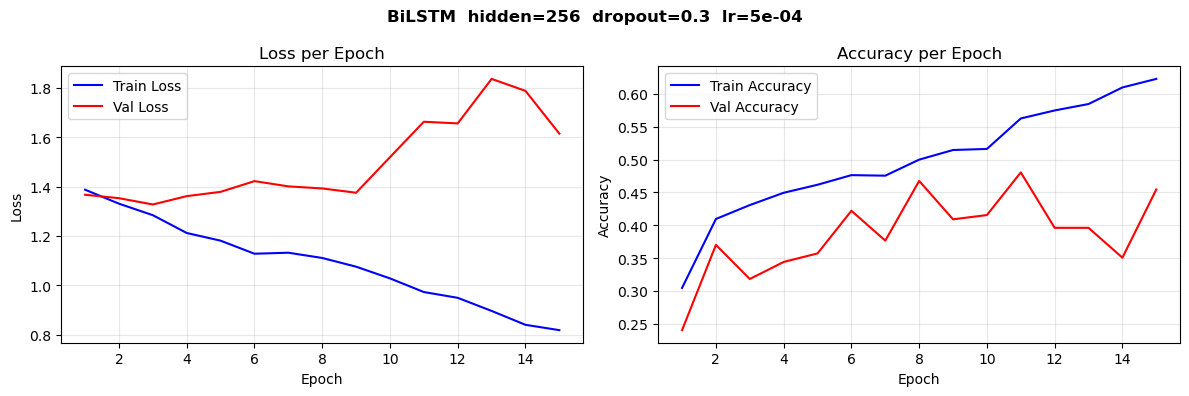


Re-training UniLSTM (15 epochs)...
Epoch  1 | Loss 1.3824 | Train Acc 0.3217 | Dev Acc 0.4351
Epoch  2 | Loss 1.3554 | Train Acc 0.3852 | Dev Acc 0.3377
Epoch  3 | Loss 1.3277 | Train Acc 0.3713 | Dev Acc 0.3831
Epoch  4 | Loss 1.2986 | Train Acc 0.4210 | Dev Acc 0.3766
Epoch  5 | Loss 1.2950 | Train Acc 0.4169 | Dev Acc 0.3961
Epoch  6 | Loss 1.2644 | Train Acc 0.4259 | Dev Acc 0.4610
Epoch  7 | Loss 1.2486 | Train Acc 0.4340 | Dev Acc 0.4286
Epoch  8 | Loss 1.2236 | Train Acc 0.4357 | Dev Acc 0.3961
Epoch  9 | Loss 1.2162 | Train Acc 0.4845 | Dev Acc 0.3961
Epoch 10 | Loss 1.2079 | Train Acc 0.4528 | Dev Acc 0.4091
Epoch 11 | Loss 1.1510 | Train Acc 0.4910 | Dev Acc 0.3831
Epoch 12 | Loss 1.1536 | Train Acc 0.4886 | Dev Acc 0.4545
Epoch 13 | Loss 1.1096 | Train Acc 0.5114 | Dev Acc 0.3701
Epoch 14 | Loss 1.1064 | Train Acc 0.4992 | Dev Acc 0.3896
Epoch 15 | Loss 1.0905 | Train Acc 0.5163 | Dev Acc 0.4286

Best dev accuracy: 0.4610


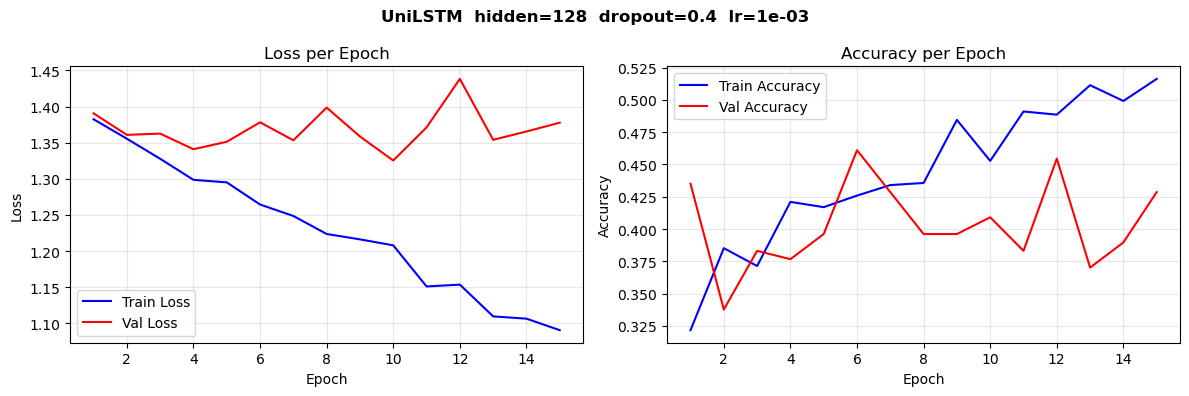


Model        Retrieved Dev   Gold Dev       Params
-----------------------------------------------------------------
BiLSTM              0.4805     0.5130    4,007,172
UniLSTM             0.4610     0.4481      707,204

BiLSTM classification report:
                 precision    recall  f1-score   support

       SUPPORTS       0.58      0.62      0.60        68
        REFUTES       0.55      0.41      0.47        27
NOT_ENOUGH_INFO       0.37      0.46      0.41        41
       DISPUTED       0.20      0.11      0.14        18

       accuracy                           0.48       154
      macro avg       0.42      0.40      0.40       154
   weighted avg       0.47      0.48      0.47       154

UniLSTM classification report:
                 precision    recall  f1-score   support

       SUPPORTS       0.56      0.74      0.63        68
        REFUTES       0.36      0.37      0.36        27
NOT_ENOUGH_INFO       0.34      0.24      0.29        41
       DISPUTED       0.14    

In [85]:
# Hyperparameter grid search for BiLSTM and UniLSTM
# Searches over hidden_dim, dropout, and learning rate using pre-computed BERT embeddings.

from itertools import product

GRID = {
    'hidden_dim': [64, 128, 256],
    'dropout':    [0.3, 0.4, 0.5],
    'lr':         [1e-5, 5e-4, 1e-3, 2e-3],
}
SEARCH_EPOCHS = 20


def run_grid_search(model_cls, train_loader, dev_loader, device, grid, search_epochs):
    keys, values = list(grid.keys()), list(grid.values())
    combos = list(product(*values))
    records = []
    for i, combo in enumerate(combos, 1):
        params = dict(zip(keys, combo))
        m = model_cls(
            input_dim=768, hidden_dim=params['hidden_dim'],
            num_layers=2,  num_classes=4, dropout=params['dropout']
        ).to(device)
        _, history = train_model(
            m, train_loader, dev_loader, device,
            epochs=search_epochs, lr=params['lr'], verbose=False
        )
        best_acc = max(history['val_acc'])
        print(f"  [{i:2d}/{len(combos)}] hidden={params['hidden_dim']:3d}  "
              f"dropout={params['dropout']}  lr={params['lr']:.0e}  ->  dev={best_acc:.4f}")
        records.append({**params, 'dev_acc': best_acc})
    return pd.DataFrame(records).sort_values('dev_acc', ascending=False).reset_index(drop=True)


# ── BiLSTM grid search ────────────────────────────────────────────────────────
print("=" * 55)
print("Grid search: BiLSTM")
print("=" * 55)
bilstm_gs = run_grid_search(BiLSTMClaimClassifier, train_loader, dev_loader_ret, device,
                             GRID, SEARCH_EPOCHS)
print("\nTop-5 BiLSTM configs:")
display(bilstm_gs.head(5))

# ── UniLSTM grid search ───────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("Grid search: UniLSTM")
print("=" * 55)
unilstm_gs = run_grid_search(UniLSTMClaimClassifier, train_loader, dev_loader_ret, device,
                              GRID, SEARCH_EPOCHS)
print("\nTop-5 UniLSTM configs:")
display(unilstm_gs.head(5))

# ── Re-train best configs for full 15 epochs ─────────────────────────────────
bp_bi   = bilstm_gs.iloc[0]
bp_uni  = unilstm_gs.iloc[0]
print(f"\nBest BiLSTM:  hidden={int(bp_bi['hidden_dim'])}  dropout={bp_bi['dropout']}  lr={bp_bi['lr']:.0e}")
print(f"Best UniLSTM: hidden={int(bp_uni['hidden_dim'])}  dropout={bp_uni['dropout']}  lr={bp_uni['lr']:.0e}")

print("\nRe-training BiLSTM (15 epochs)...")
model_bilstm = BiLSTMClaimClassifier(
    input_dim=768, hidden_dim=int(bp_bi['hidden_dim']),
    num_layers=2,  num_classes=4, dropout=float(bp_bi['dropout'])
).to(device)
model_bilstm, bilstm_hist = train_model(
    model_bilstm, train_loader, dev_loader_ret, device,
    epochs=15, lr=float(bp_bi['lr'])
)
plot_training_history(
    bilstm_hist,
    f"BiLSTM  hidden={int(bp_bi['hidden_dim'])}  dropout={bp_bi['dropout']}  lr={bp_bi['lr']:.0e}"
)

print("\nRe-training UniLSTM (15 epochs)...")
model_unilstm = UniLSTMClaimClassifier(
    input_dim=768, hidden_dim=int(bp_uni['hidden_dim']),
    num_layers=2,  num_classes=4, dropout=float(bp_uni['dropout'])
).to(device)
model_unilstm, unilstm_hist = train_model(
    model_unilstm, train_loader, dev_loader_ret, device,
    epochs=15, lr=float(bp_uni['lr'])
)
plot_training_history(
    unilstm_hist,
    f"UniLSTM  hidden={int(bp_uni['hidden_dim'])}  dropout={bp_uni['dropout']}  lr={bp_uni['lr']:.0e}"
)

# ── Final evaluation & model selection ───────────────────────────────────────
bilstm_acc,  (bilstm_preds,  dev_ret_labels) = evaluate(model_bilstm,  dev_loader_ret, device)
unilstm_acc, (unilstm_preds, _)              = evaluate(model_unilstm, dev_loader_ret, device)
bilstm_gold,  _                              = evaluate(model_bilstm,  dev_loader,     device)
unilstm_gold, _                              = evaluate(model_unilstm, dev_loader,     device)

print("\n" + "=" * 65)
print(f"{'Model':<10} {'Retrieved Dev':>15} {'Gold Dev':>10} {'Params':>12}")
print("-" * 65)
print(f"{'BiLSTM':<10} {bilstm_acc:>15.4f} {bilstm_gold:>10.4f} "
      f"{sum(p.numel() for p in model_bilstm.parameters()):>12,}")
print(f"{'UniLSTM':<10} {unilstm_acc:>15.4f} {unilstm_gold:>10.4f} "
      f"{sum(p.numel() for p in model_unilstm.parameters()):>12,}")
print("=" * 65)

print("\nBiLSTM classification report:")
print(classification_report(dev_ret_labels, bilstm_preds,
                             target_names=[IDX2LABEL[i] for i in range(4)], zero_division=0))
print("UniLSTM classification report:")
print(classification_report(dev_ret_labels, unilstm_preds,
                             target_names=[IDX2LABEL[i] for i in range(4)], zero_division=0))

model      = model_bilstm  if bilstm_acc >= unilstm_acc else model_unilstm
model_name = "BiLSTM"      if bilstm_acc >= unilstm_acc else "UniLSTM"
print(f"\nSelected: {model_name}  (dev acc = {max(bilstm_acc, unilstm_acc):.4f})")

Loading roberta-base...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



  RoBERTa-base + BiLSTM
  -> train (retrieved)...
  -> dev (gold)...
  -> dev (retrieved)...
Epoch  1 | Loss 1.3975 | Train Acc 0.3265 | Dev Acc 0.2208
Epoch  2 | Loss 1.3890 | Train Acc 0.3265 | Dev Acc 0.4545
Epoch  3 | Loss 1.3844 | Train Acc 0.2989 | Dev Acc 0.4286
Epoch  4 | Loss 1.3801 | Train Acc 0.3306 | Dev Acc 0.4286
Epoch  5 | Loss 1.3845 | Train Acc 0.2989 | Dev Acc 0.3636
Epoch  6 | Loss 1.3688 | Train Acc 0.3412 | Dev Acc 0.4351
Epoch  7 | Loss 1.3763 | Train Acc 0.3493 | Dev Acc 0.4351
Epoch  8 | Loss 1.3730 | Train Acc 0.3485 | Dev Acc 0.4286
Epoch  9 | Loss 1.3673 | Train Acc 0.3836 | Dev Acc 0.4610
Epoch 10 | Loss 1.3710 | Train Acc 0.3575 | Dev Acc 0.4610
Epoch 11 | Loss 1.3545 | Train Acc 0.3917 | Dev Acc 0.4416
Epoch 12 | Loss 1.3595 | Train Acc 0.3730 | Dev Acc 0.4545
Epoch 13 | Loss 1.3533 | Train Acc 0.3803 | Dev Acc 0.4740
Epoch 14 | Loss 1.3601 | Train Acc 0.3648 | Dev Acc 0.4286
Epoch 15 | Loss 1.3473 | Train Acc 0.3827 | Dev Acc 0.4935
Epoch 16 | Loss 1.345

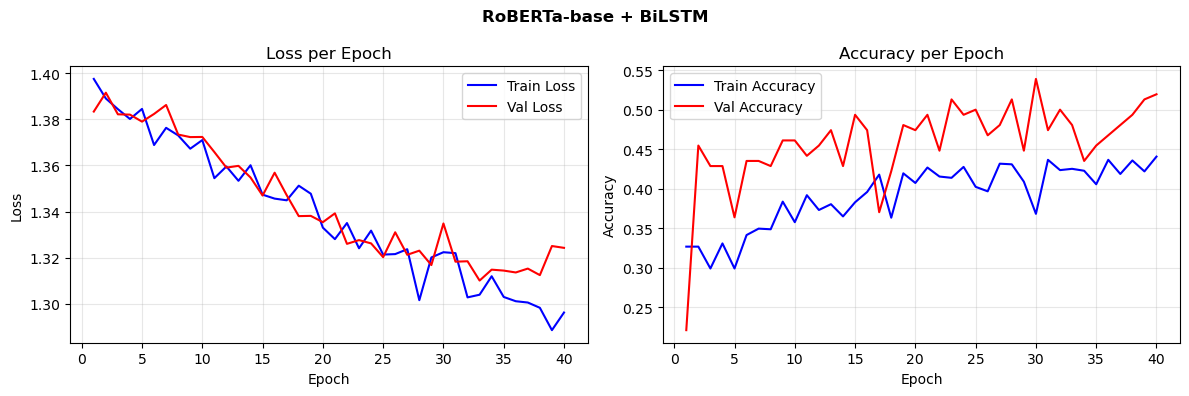


Loading microsoft/deberta-v3-base...

  DeBERTa-v3-base + BiLSTM (mean pool)
  -> train (retrieved)...
  -> dev (gold)...
  -> dev (retrieved)...
Epoch  1 | Loss 1.4106 | Train Acc 0.2899 | Dev Acc 0.1753
Epoch  2 | Loss 1.3869 | Train Acc 0.3119 | Dev Acc 0.4545
Epoch  3 | Loss 1.3667 | Train Acc 0.3681 | Dev Acc 0.4416
Epoch  4 | Loss 1.3416 | Train Acc 0.4267 | Dev Acc 0.3701
Epoch  5 | Loss 1.3338 | Train Acc 0.3738 | Dev Acc 0.4481
Epoch  6 | Loss 1.2990 | Train Acc 0.4349 | Dev Acc 0.4545
Epoch  7 | Loss 1.3044 | Train Acc 0.4137 | Dev Acc 0.4481
Epoch  8 | Loss 1.2827 | Train Acc 0.4577 | Dev Acc 0.4610
Epoch  9 | Loss 1.2870 | Train Acc 0.4169 | Dev Acc 0.4286
Epoch 10 | Loss 1.2610 | Train Acc 0.4397 | Dev Acc 0.4740
Epoch 11 | Loss 1.2420 | Train Acc 0.4495 | Dev Acc 0.4545
Epoch 12 | Loss 1.2443 | Train Acc 0.4642 | Dev Acc 0.4286
Epoch 13 | Loss 1.2231 | Train Acc 0.4715 | Dev Acc 0.5000
Epoch 14 | Loss 1.2060 | Train Acc 0.4862 | Dev Acc 0.4740
Epoch 15 | Loss 1.2149 | Tr

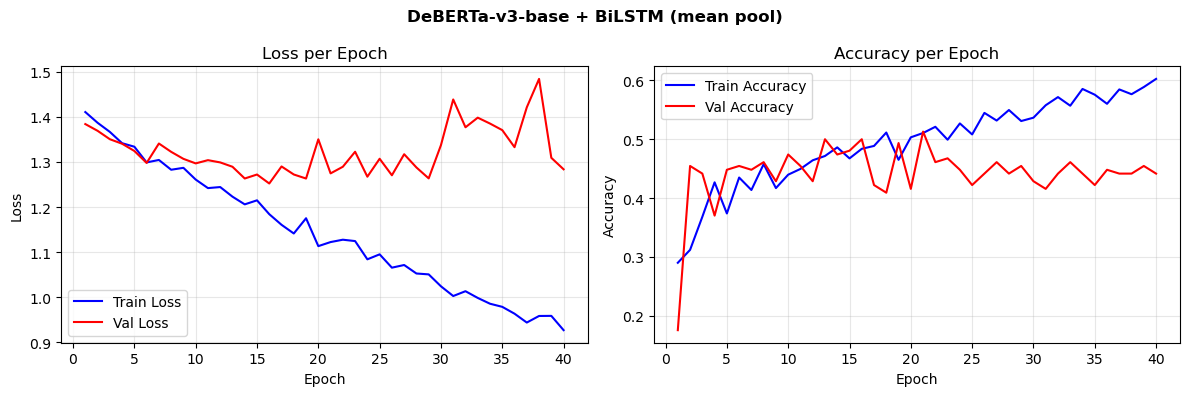


Encoder                  Retrieved Dev   Gold Dev
-----------------------------------------------------------------
BERT-base                       0.4805     0.5130
RoBERTa-base                    0.5390     0.5390
DeBERTa-v3-base                 0.5130     0.4935

Best encoder: RoBERTa-base  (retrieved dev acc = 0.5390)


In [109]:
# Encoder comparison: RoBERTa-base and DeBERTa-v3-base vs BERT-base
# Each encoder is frozen; a fresh BiLSTM classifier is trained on top.
# BERT and RoBERTa use [CLS] pooling; DeBERTa-v3 uses mean pooling

def build_enc_loaders(encoder, enc_tokenizer, bs=32, pooling='cls'):
    print("  -> train (retrieved)...")
    ds_tr  = ClaimEvidenceDataset(train_claims_ret, evidence_corpus, LABEL2IDX,
                                   encoder, enc_tokenizer, device, pooling=pooling)
    print("  -> dev (gold)...")
    ds_dv  = ClaimEvidenceDataset(dev_claims,       evidence_corpus, LABEL2IDX,
                                   encoder, enc_tokenizer, device, pooling=pooling)
    print("  -> dev (retrieved)...")
    ds_dvr = ClaimEvidenceDataset(dev_claims_ret,   evidence_corpus, LABEL2IDX,
                                   encoder, enc_tokenizer, device, pooling=pooling)
    return (DataLoader(ds_tr,  batch_size=bs, shuffle=True,  collate_fn=collate_fn),
            DataLoader(ds_dv,  batch_size=bs, shuffle=False, collate_fn=collate_fn),
            DataLoader(ds_dvr, batch_size=bs, shuffle=False, collate_fn=collate_fn))

def run_encoder_experiment_roberta(label, encoder, enc_tokenizer, pooling='cls'):
    print(f"\n{'='*55}\n  {label}\n{'='*55}")
    tr_loader, dv_loader, dvr_loader = build_enc_loaders(encoder, enc_tokenizer, pooling=pooling)
    m = BiLSTMClaimClassifier(
        input_dim=768, hidden_dim=64, num_layers=2, num_classes=4, dropout=0.5
    ).to(device)
    m, hist = train_model(m, tr_loader, dvr_loader, device, epochs=40, lr=1e-3)
    plot_training_history(hist, label)
    ret_acc,  _ = evaluate(m, dvr_loader, device)
    gold_acc, _ = evaluate(m, dv_loader,  device)
    return m, dv_loader, dvr_loader, ret_acc, gold_acc


def run_encoder_experiment_deberta(label, encoder, enc_tokenizer, pooling='cls'):
    print(f"\n{'='*55}\n  {label}\n{'='*55}")
    tr_loader, dv_loader, dvr_loader = build_enc_loaders(encoder, enc_tokenizer, pooling=pooling)
    m = BiLSTMClaimClassifier(
        input_dim=768, hidden_dim=64, num_layers=2, num_classes=4, dropout=0.4
    ).to(device)
    m, hist = train_model(m, tr_loader, dvr_loader, device, epochs=40, lr=1e-3)
    plot_training_history(hist, label)
    ret_acc,  _ = evaluate(m, dvr_loader, device)
    gold_acc, _ = evaluate(m, dv_loader,  device)
    return m, dv_loader, dvr_loader, ret_acc, gold_acc


results = []

# BERT-base (already trained in the previous cell — reuse existing model)
bert_ret,  _ = evaluate(model_bilstm, dev_loader_ret, device)
bert_gold, _ = evaluate(model_bilstm, dev_loader,     device)
results.append(('BERT-base', bert_ret, bert_gold,
                model_bilstm, tokenizer, bert, dev_loader_ret, 'cls'))

# ── RoBERTa-base (CLS pooling) ────────────────────────────────────────────────
try:
    print("Loading roberta-base...")
    rob_tokenizer = AutoTokenizer.from_pretrained('roberta-base')
    rob_encoder   = AutoModel.from_pretrained('roberta-base').to(device)
    for p in rob_encoder.parameters(): p.requires_grad = False
    rob_encoder.eval()
    model_rob, dev_loader_rob, dev_loader_rob_ret, rob_ret, rob_gold = \
        run_encoder_experiment_roberta("RoBERTa-base + BiLSTM", rob_encoder, rob_tokenizer, pooling='cls')
    results.append(('RoBERTa-base', rob_ret, rob_gold,
                    model_rob, rob_tokenizer, rob_encoder, dev_loader_rob_ret, 'cls'))
except Exception as e:
    print(f"RoBERTa skipped: {e}")

# ── DeBERTa-v3-base (mean pooling) ────────────────────────────────────────────
try:
    print("\nLoading microsoft/deberta-v3-base...")
    deb_tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-base')
    deb_encoder   = AutoModel.from_pretrained('microsoft/deberta-v3-base').to(device)
    for p in deb_encoder.parameters(): p.requires_grad = False
    deb_encoder.eval()
    model_deb, dev_loader_deb, dev_loader_deb_ret, deb_ret, deb_gold = \
        run_encoder_experiment_deberta("DeBERTa-v3-base + BiLSTM (mean pool)",
                               deb_encoder, deb_tokenizer, pooling='mean')
    results.append(('DeBERTa-v3-base', deb_ret, deb_gold,
                    model_deb, deb_tokenizer, deb_encoder, dev_loader_deb_ret, 'mean'))
except Exception as e:
    print(f"DeBERTa skipped: {e}")

print("\n" + "=" * 65)
print(f"{'Encoder':<22} {'Retrieved Dev':>15} {'Gold Dev':>10}")
print("-" * 65)
for name, ret, gold, *_ in results:
    print(f"{name:<22} {ret:>15.4f} {gold:>10.4f}")
print("=" * 65)

# Select the best encoder by retrieved-evidence dev accuracy
best_name, best_ret, best_gold, \
    best_encoder_model, best_encoder_tokenizer, best_encoder, best_dev_loader, best_pooling = \
    max(results, key=lambda r: r[1])

print(f"\nBest encoder: {best_name}  (retrieved dev acc = {best_ret:.4f})")

# 3.Testing and Evaluation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [110]:
# Test predictions - generated using the best encoder + classifier


_, (preds, labels) = evaluate(best_encoder_model, best_dev_loader, device)
print("Dev set report (retrieved evidence):")
print(classification_report(labels, preds, target_names=[IDX2LABEL[i] for i in range(4)],
                             zero_division=0))

# Build test dataset with the same pooling strategy as the winning encoder
test_dataset = ClaimEvidenceDataset(
    test_claims_ret, evidence_corpus, LABEL2IDX,
    best_encoder, best_encoder_tokenizer, device, has_labels=False, pooling=best_pooling
)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
_, (test_preds, _) = evaluate(best_encoder_model, test_loader, device)

# Build output with both claim_label AND evidences (required by eval.py)
test_output = {}
for (cid, item), pred in zip(test_claims_ret.items(), test_preds):
    test_output[cid] = {
        'claim_label': IDX2LABEL[pred],
        'evidences': item['evidences']
    }

with open('data/test-claims-predictions.json', 'w') as f:
    json.dump(test_output, f, indent=2)

pred_dist = Counter(v['claim_label'] for v in test_output.values())
print(f"\nPrediction distribution: {dict(pred_dist)}")
print("Saved to data/test-claims-predictions.json")

Dev set report (retrieved evidence):
                 precision    recall  f1-score   support

       SUPPORTS       0.68      0.65      0.66        68
        REFUTES       0.57      0.44      0.50        27
NOT_ENOUGH_INFO       0.40      0.66      0.50        41
       DISPUTED       0.00      0.00      0.00        18

       accuracy                           0.54       154
      macro avg       0.41      0.44      0.41       154
   weighted avg       0.50      0.54      0.51       154


Prediction distribution: {'SUPPORTS': 58, 'NOT_ENOUGH_INFO': 64, 'REFUTES': 31}
Saved to data/test-claims-predictions.json


In [111]:
# Generated dev predictions

dev_output = {}
for (cid, item), pred in zip(dev_claims_ret.items(), preds):
    dev_output[cid] = {
        'claim_label': IDX2LABEL[pred],
        'evidences': item['evidences']
    }

with open('data/dev-claims-predictions.json', 'w') as f:
    json.dump(dev_output, f, indent=2)

print("Dev predictions saved!")

Dev predictions saved!


In [112]:
# Run Official Evaluation Script
# Reports evidence retrieval F-score, claim classification accuracy, and harmonic Mean

!python eval.py \
    --predictions data/dev-claims-predictions.json \
    --groundtruth data/dev-claims.json

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Evidence Retrieval F-score (F)    = 0.24652648938363222
Claim Classification Accuracy (A) = 0.538961038961039
Harmonic Mean of F and A          = 0.33830753017715015


In [113]:
# For submission on leaderboard

import zipfile
import json

sample_cid = list(test_output.keys())[0]
print("Sample output entry:")
print(json.dumps({sample_cid: test_output[sample_cid]}, indent=2))

assert all('claim_label' in v for v in test_output.values()), "Missing claim_label!"
assert all('evidences' in v and len(v['evidences']) > 0 for v in test_output.values()), "Missing/empty evidences!"
assert all(v['claim_label'] in ['SUPPORTS', 'REFUTES', 'NOT_ENOUGH_INFO', 'DISPUTED'] for v in test_output.values()), "Invalid label!"

print(f"\nAll {len(test_output)} predictions validated!")
print(f"Label distribution: {dict(Counter(v['claim_label'] for v in test_output.values()))}")

with open('data/test-output.json', 'w') as f:
    json.dump(test_output, f, indent=2)

with zipfile.ZipFile('data/submission.zip', 'w') as z:
    z.write('data/test-output.json', 'test-output.json')

print("\nSubmission zip created at data/submission.zip")

Sample output entry:
{
  "claim-2967": {
    "claim_label": "SUPPORTS",
    "evidences": [
      "evidence-219780",
      "evidence-632574",
      "evidence-963856",
      "evidence-905191",
      "evidence-770933"
    ]
  }
}

All 153 predictions validated!
Label distribution: {'SUPPORTS': 58, 'NOT_ENOUGH_INFO': 64, 'REFUTES': 31}

Submission zip created at data/submission.zip


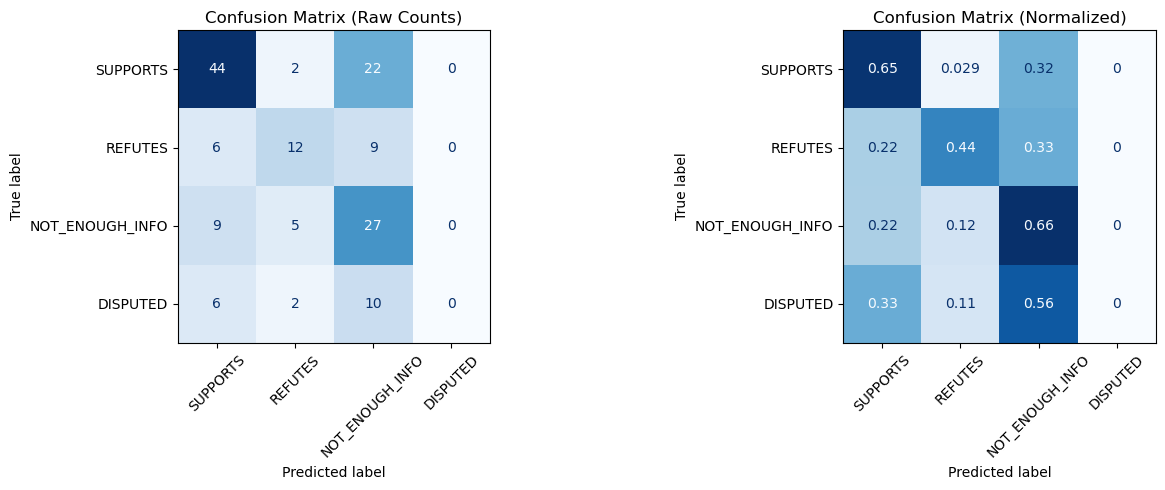

In [114]:
# Confusion matrix

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

_, (best_preds, best_labels) = evaluate(best_encoder_model, best_dev_loader, device)

label_names = ['SUPPORTS', 'REFUTES', 'NOT_ENOUGH_INFO', 'DISPUTED']
cm = confusion_matrix(best_labels, best_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Raw Counts)')
axes[0].tick_params(axis='x', rotation=45)

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=label_names)
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('data/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [116]:
# Parameters - reflects all hyperparameters actually used in this notebook

import pandas as pd

hyperparams = pd.DataFrame({
    'Component': [
        'BM25 Retrieval', 'BM25 Retrieval',
        'Transformer Re-ranker', 'Transformer Re-ranker',
        'NLI Verdict Classifier', 'NLI Verdict Classifier',
        'BiLSTM/UniLSTM Classifier', 'BiLSTM/UniLSTM Classifier',
        'BiLSTM/UniLSTM Classifier', 'BiLSTM/UniLSTM Classifier',
        'BiLSTM/UniLSTM Classifier', 'BiLSTM/UniLSTM Classifier',
        'Training', 'Training', 'Training',
    ],
    'Hyperparameter': [
        'Corpus', 'Top-n candidates',
        'Model', 'Max sequence length',
        'Model', 'Threshold',
        'Encoder', 'Input dimension',
        'Hidden dimension', 'Num layers',
        'Dropout', 'Num classes',
        'Epochs', 'Learning rate', 'Batch size',
    ],
    'Value': [
        'Curated pool (3,443 passages)', '50',
        'cross-encoder/ms-marco-MiniLM-L-6-v2', '512',
        'cross-encoder/nli-MiniLM2-L6-H768', '0.10',
        'RoBERTa-base', '768',
        '64', '2',
        '0.5', '4',
        '15', '1e-3', '32',
    ],
    'Justification': [
        'Higher quality climate-specific passages', 'Balance between recall and speed',
        'Best performing MS-MARCO cross-encoder', 'Handles long climate claims',
        'Lightweight NLI model for per-sentence classification', 'Empirically tuned on dev set',
        'Best dev accuracy (0.5260) vs BERT (0.4740) and DeBERTa (0.3506)', 'BERT/RoBERTa hidden size',
        'Sufficient capacity for 4-class problem', 'Balances depth and overfitting',
        'Regularisation for small dataset', '4-class classification task',
        'Sufficient for convergence', 'Standard Adam learning rate', 'Fits within Colab memory constraints',
    ]
})

display(hyperparams)

,Component,Hyperparameter,Value,Justification
0,BM25 Retrieval,Corpus,"Curated pool (3,443 passages)",Higher quality climate-specific passages
1,BM25 Retrieval,Top-n candidates,50,Balance between recall and speed
2,Transformer Re-ranker,Model,cross-encoder/ms-marco-MiniLM-L-6-v2,Best performing MS-MARCO cross-encoder
3,Transformer Re-ranker,Max sequence length,512,Handles long climate claims
4,NLI Verdict Classifier,Model,cross-encoder/nli-MiniLM2-L6-H768,Lightweight NLI model for per-sentence classif...
5,NLI Verdict Classifier,Threshold,0.10,Empirically tuned on dev set
6,BiLSTM/UniLSTM Classifier,Encoder,RoBERTa-base,Best dev accuracy (0.5260) vs BERT (0.4740) an...
7,BiLSTM/UniLSTM Classifier,Input dimension,768,BERT/RoBERTa hidden size
8,BiLSTM/UniLSTM Classifier,Hidden dimension,64,Sufficient capacity for 4-class problem
9,BiLSTM/UniLSTM Classifier,Num layers,2,Balances depth and overfitting


## Object Oriented Programming codes here

*You can use multiple code snippets. Just add more if needed*

The OOP classes used in this project are defined inline in Section 2:
- ClaimEvidenceDataset (Section 2.8)
- BiLSTMClaimClassifier (Section 2.9)
- UniLSTMClaimClassifier (Section 2.9)